# Notebook 1 — Otimização de Hiperparâmetros com Optuna (TPE)

Estimação de Parva por Árvore (TPE), amostrador bayesiano
não-paramétrico. Em cada trial, o TPE ajusta modelos de densidade separados
para regiões de alto e baixo desempenho e sugere o próximo ponto.

**Pipeline:**
1. Simula osciladores com integrador de Störmer-Verlet
2. Pré-computa dataset (uma vez por σ_J × seed)
3. Executa Optuna para HPO
4. Salva resultados em results/optuna_results.json

In [1]:
import sys, os
sys.path.insert(0, "..")   # ajuste se common.py estiver em pasta diferente
os.makedirs("results", exist_ok=True)
os.makedirs("sim_cache", exist_ok=True)

import numpy as np
import torch
import json
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from common import (
    get_device, device_info, load_or_simulate, extract_dataset,
    make_objective, compute_metrics, encode_params,
    SIGMA_LEVELS, N_TRIALS, N_SEEDS, N_OSCILLATORS, LAM,
    T_SPAN, DT, N_TRAJS, SAVE_EVERY, N_EPOCHS_OBJ, PATIENCE_OBJ,
    SIM_CACHE_DIR, RESULTS_DIR, ACTIVATIONS, BATCH_SIZES,
)

DEVICE = get_device()
print(f"Device: {device_info(DEVICE)}")
print(f"Configuração: N={N_OSCILLATORS}, λ={LAM}, n_trajs={N_TRAJS}")
print(f"              n_trials={N_TRIALS}, n_seeds={N_SEEDS}")
print(f"              σ_J levels: {SIGMA_LEVELS}")

Device: CUDA — NVIDIA GeForce RTX 3060 (12.5 GB)
Configuração: N=8, λ=0.1, n_trajs=200
              n_trials=50, n_seeds=3
              σ_J levels: [0.0, 0.5, 1.0, 2.0]


In [2]:
def run_optuna(objective_fn, n_trials: int, seed: int) -> dict:
    """
    Executa otimização Optuna (TPE) e retorna histórico e melhores resultados.

    O TPE mantém modelos de densidade l(x) (bons) e g(x) (ruins) e
    sugere o próximo ponto maximizando EI = l(x)/g(x).
    """
    all_params_encoded = []   # para SHAP posterior

    def optuna_objective(trial):
        params = {
            "lr":           trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            "hidden_dim":   trial.suggest_int("hidden_dim", 32, 256),
            "n_layers":     trial.suggest_int("n_layers", 1, 4),
            "activation":   trial.suggest_categorical("activation",
                                ["tanh", "silu", "gelu", "softplus"]),
            "batch_size":   trial.suggest_categorical("batch_size",
                                [64, 128, 256, 512]),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        }
        val_loss = objective_fn(params)
        all_params_encoded.append(encode_params(params))
        return val_loss

    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(optuna_objective, n_trials=n_trials, show_progress_bar=False)

    return {
        "best_value":          float(study.best_value),
        "best_params":         study.best_params,
        "history":             [float(t.value) for t in study.trials],
        "all_params_encoded":  all_params_encoded,
        "metrics":             compute_metrics([t.value for t in study.trials]),
    }

In [3]:
results = {}

for sigma_J in SIGMA_LEVELS:
    results[str(sigma_J)] = {}
    print(f"\n{'='*50}")
    print(f"sigma_J = {sigma_J}")
    print(f"{'='*50}")

    for seed in range(N_SEEDS):
        print(f"  Seed {seed}/{N_SEEDS-1}", end=" | ", flush=True)

        # ── Simulação (carrega do cache se já existir) ────────────────────────
        J_np, states = load_or_simulate(
            SIM_CACHE_DIR, N_OSCILLATORS, sigma_J, LAM,
            N_TRAJS, T_SPAN, DT, DEVICE, seed, SAVE_EVERY,
        )
        X, Y = extract_dataset(states, J_np, LAM)
        print(f"Dataset: {len(X):,} amostras", end=" | ", flush=True)

        # ── Optuna ────────────────────────────────────────────────────────────
        objective_fn = make_objective(X, Y, N_OSCILLATORS, DEVICE,
                                      n_epochs=N_EPOCHS_OBJ,
                                      patience=PATIENCE_OBJ)
        res = run_optuna(objective_fn, N_TRIALS, seed)
        results[str(sigma_J)][str(seed)] = res

        best = res["best_value"]
        t10  = res["metrics"]["t10"]
        print(f"Best val_loss={best:.4e}, t10={t10}", flush=True)

# Salva resultados
os.makedirs(RESULTS_DIR, exist_ok=True)
out_path = os.path.join(RESULTS_DIR, "optuna_results.json")
with open(out_path, "w") as f:
    json.dump({"method": "optuna", "results": results}, f, indent=2)

print(f"\nResultados salvos em: {out_path}")


sigma_J = 0.0
  Seed 0/2 | 

Dataset: 40,000 amostras | 

Best val_loss=3.6176e-05, t10=37


  Seed 1/2 | 

Dataset: 40,000 amostras | 

...

Best val_loss=3.8148e-04, t10=44


  Seed 2/2 | 

Dataset: 40,000 amostras | 

Best val_loss=7.3251e-04, t10=14



Resultados salvos em: results/optuna_results.json


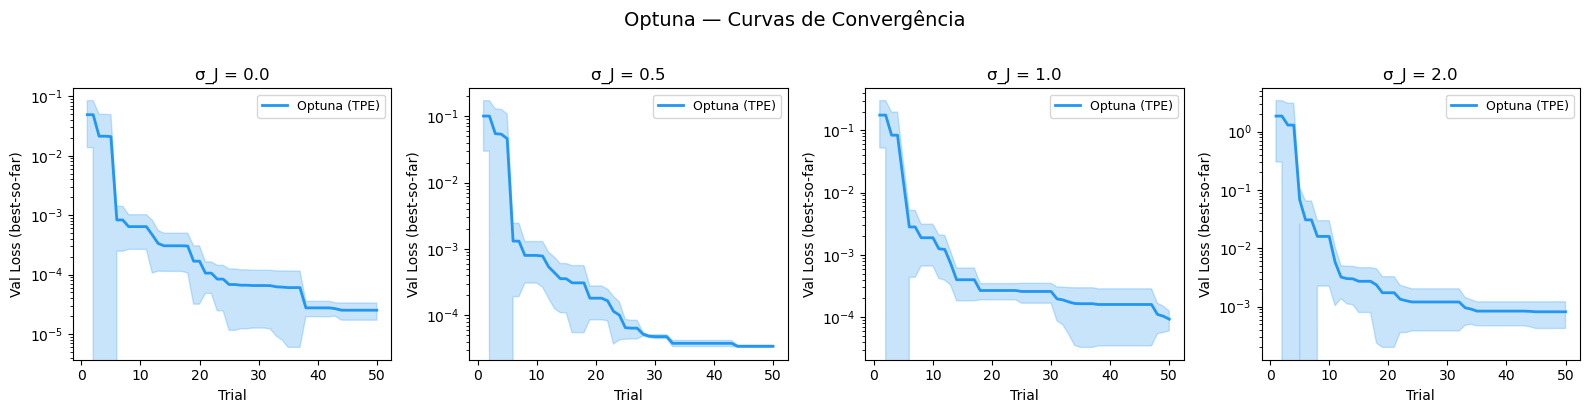

Plot salvo.


In [4]:
# Visualização rápida de convergência (por sigma_J)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(SIGMA_LEVELS), figsize=(16, 4), sharey=False)
color = "#2196F3"

for ax, sigma_J in zip(axes, SIGMA_LEVELS):
    histories = [
        np.minimum.accumulate(
            results[str(sigma_J)][str(s)]["history"]
        )
        for s in range(N_SEEDS)
    ]
    # Alinhar comprimentos (early stopping pode terminar em momentos diferentes)
    max_len = max(len(h) for h in histories)
    padded = [np.pad(h, (0, max_len - len(h)), mode="edge") for h in histories]

    mean = np.mean(padded, axis=0)
    std  = np.std(padded, axis=0)
    trials = np.arange(1, len(mean) + 1)

    ax.plot(trials, mean, color=color, lw=2, label="Optuna (TPE)")
    ax.fill_between(trials, mean - std, mean + std, alpha=0.25, color=color)
    ax.set_title(f"σ_J = {sigma_J}", fontsize=12)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Val Loss (best-so-far)")
    ax.set_yscale("log")
    ax.legend(fontsize=9)

plt.suptitle("Optuna — Curvas de Convergência", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "optuna_convergence.pdf"), bbox_inches="tight", dpi=150)
plt.show()
print("Plot salvo.")